# 05 Diffusion Innovation Model

This notebook trains a simple DDPM-style diffusion model on VAR residuals.

Goal:

Fit a flexible innovation generator to residuals and compare generated diffusion shocks against empirical residuals and classical innovation baselines.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

import torch
from torch.utils.data import DataLoader, TensorDataset

from src.utils.seeds import set_seed
from src.utils.device import get_device
from src.utils.logging_utils import make_run_dir, save_metrics_json, save_table_csv
from src.data.loaders import load_npz, save_npz

from src.diffusion.schedules import make_ddpm_schedule
from src.diffusion.networks import ResidualDenoisingMLP
from src.diffusion.forward import q_sample
from src.diffusion.trainer import train_diffusion_model
from src.diffusion.sampler import sample_diffusion_innovations

from src.innovations.diagnostics import summarize_innovations

set_seed(123)
device = get_device()
device

device(type='mps')

In [2]:
dgp_names = [
    "gaussian",
    "student_t",
    "mixture",
    "heteroskedastic",
]

T = 200
beta_start = 1e-4
beta_end = 2e-2

batch_size = 64
epochs = 1500
lr = 5e-4

hidden_dim = 256
time_embedding_dim = 64

n_samples = 10_000

resid_dir = ROOT / "results" / "residuals" / "03_residuals"
diffusion_dir = ROOT / "results" / "innovations" / "05_diffusion"
table_dir = ROOT / "results" / "tables" / "05_diffusion"
model_dir = ROOT / "results" / "models" / "05_diffusion"

diffusion_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)

In [3]:
residual_store = {}

for name in dgp_names:
    path = resid_dir / f"{name}_var_residuals.npz"
    data = load_npz(path)
    residuals = data["residuals"]

    residual_store[name] = residuals
    print(name, residuals.shape)

gaussian (299, 3)
student_t (299, 3)
mixture (299, 3)
heteroskedastic (299, 3)


In [4]:
diffusion_models = {}
diffusion_samples = {}
scalers = {}
loss_histories = {}

schedule = make_ddpm_schedule(
    timesteps=T,
    beta_start=beta_start,
    beta_end=beta_end,
    schedule_type="linear",
    device=device,
)

for dgp_name, residuals in residual_store.items():
    print(f"\nTraining diffusion model for: {dgp_name}")

    mu = residuals.mean(axis=0)
    sigma = residuals.std(axis=0, ddof=1)
    sigma = np.where(sigma < 1e-8, 1.0, sigma)

    residuals_std = (residuals - mu) / sigma
    input_dim = residuals_std.shape[1]

    model = ResidualDenoisingMLP(
        input_dim=input_dim,
        time_embedding_dim=time_embedding_dim,
        hidden_dim=hidden_dim,
        num_hidden_layers=2,
        dropout=0.0,
    ).to(device)

    loss_history = train_diffusion_model(
        model=model,
        residuals=residuals_std,
        schedule=schedule,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        device=device,
        verbose=True,
    )

    samples_paths = sample_diffusion_innovations(
        model=model,
        n_paths=n_samples,
        horizon=1,
        input_dim=input_dim,
        schedule=schedule,
        device=device,
        mean=mu,
        std=sigma,
    )

    samples = samples_paths[:, 0, :]

    diffusion_models[dgp_name] = model
    diffusion_samples[dgp_name] = samples
    scalers[dgp_name] = {
        "mu": mu,
        "sigma": sigma,
    }
    loss_histories[dgp_name] = loss_history["loss"]

    torch.save(
        model.state_dict(),
        model_dir / f"{dgp_name}_diffusion_model.pt",
    )

    save_npz(
        diffusion_dir / f"{dgp_name}_diffusion_innovations.npz",
        innovations=samples,
        residual_mean=mu,
        residual_std=sigma,
    )

    print("saved:", diffusion_dir / f"{dgp_name}_diffusion_innovations.npz")


Training diffusion model for: gaussian
Epoch 0001 | loss = 0.921669
Epoch 0025 | loss = 0.616193
Epoch 0050 | loss = 0.597984
Epoch 0075 | loss = 0.585208
Epoch 0100 | loss = 0.549874
Epoch 0125 | loss = 0.546590
Epoch 0150 | loss = 0.637594
Epoch 0175 | loss = 0.518083
Epoch 0200 | loss = 0.561202
Epoch 0225 | loss = 0.605418
Epoch 0250 | loss = 0.648174
Epoch 0275 | loss = 0.570938
Epoch 0300 | loss = 0.649249
Epoch 0325 | loss = 0.566281
Epoch 0350 | loss = 0.562298
Epoch 0375 | loss = 0.593162
Epoch 0400 | loss = 0.607199
Epoch 0425 | loss = 0.632259
Epoch 0450 | loss = 0.598511
Epoch 0475 | loss = 0.592949
Epoch 0500 | loss = 0.634433
Epoch 0525 | loss = 0.658711
Epoch 0550 | loss = 0.538749
Epoch 0575 | loss = 0.617102
Epoch 0600 | loss = 0.608105
Epoch 0625 | loss = 0.521130
Epoch 0650 | loss = 0.594840
Epoch 0675 | loss = 0.583013
Epoch 0700 | loss = 0.584998
Epoch 0725 | loss = 0.549992
Epoch 0750 | loss = 0.574860
Epoch 0775 | loss = 0.600902
Epoch 0800 | loss = 0.645353
Epo

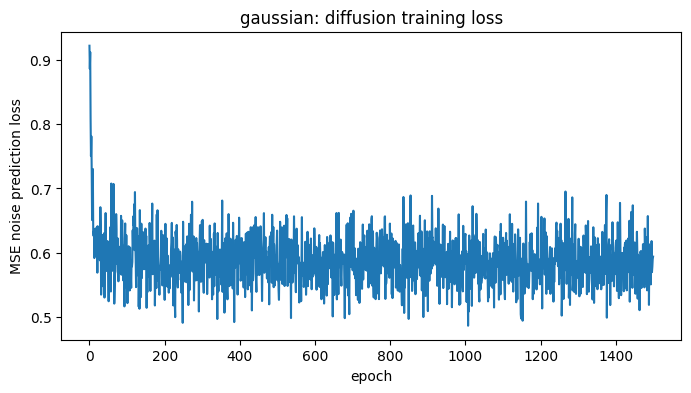

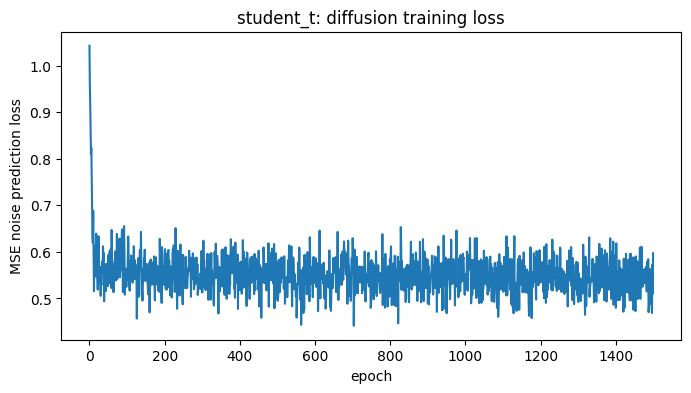

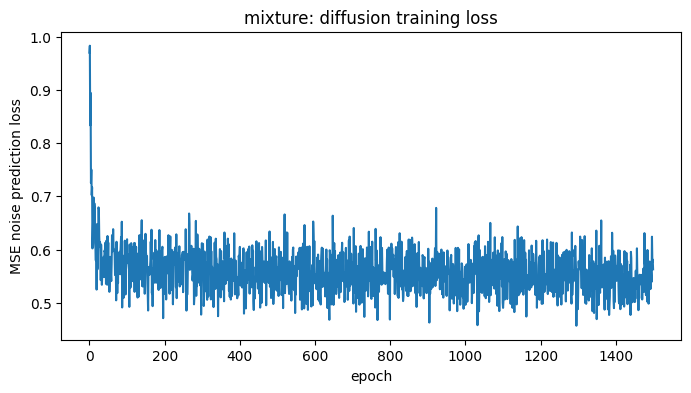

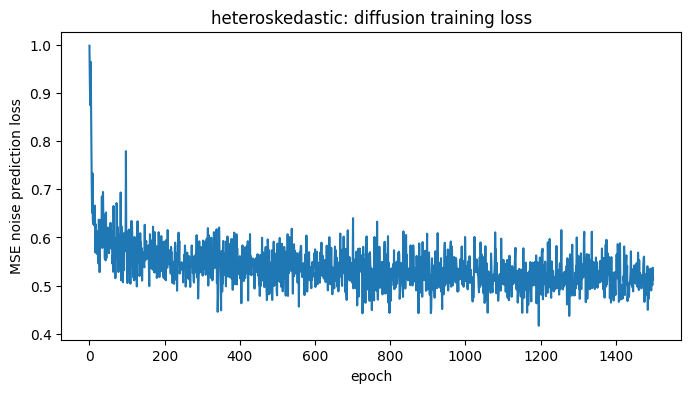

In [5]:
for dgp_name, losses in loss_histories.items():
    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.title(f"{dgp_name}: diffusion training loss")
    plt.xlabel("epoch")
    plt.ylabel("MSE noise prediction loss")
    plt.show()

In [6]:
rows = []

for dgp_name in dgp_names:
    empirical = residual_store[dgp_name]
    generated = diffusion_samples[dgp_name]

    emp_diag = summarize_innovations(empirical)
    gen_diag = summarize_innovations(generated)

    for j in range(empirical.shape[1]):
        rows.append({
            "dgp": dgp_name,
            "series": j + 1,
            "source": "empirical_residuals",
            "mean": emp_diag["mean"][j],
            "std": emp_diag["std"][j],
            "skewness": emp_diag["skewness"][j],
            "kurtosis": emp_diag["kurtosis"][j],
            "excess_kurtosis": emp_diag["excess_kurtosis"][j],
            "jb_pvalue": emp_diag["jarque_bera_pvalue"][j],
        })

        rows.append({
            "dgp": dgp_name,
            "series": j + 1,
            "source": "diffusion",
            "mean": gen_diag["mean"][j],
            "std": gen_diag["std"][j],
            "skewness": gen_diag["skewness"][j],
            "kurtosis": gen_diag["kurtosis"][j],
            "excess_kurtosis": gen_diag["excess_kurtosis"][j],
            "jb_pvalue": gen_diag["jarque_bera_pvalue"][j],
        })

diffusion_diag_df = pd.DataFrame(rows)
diffusion_diag_df

,dgp,series,source,mean,std,skewness,kurtosis,excess_kurtosis,jb_pvalue
0,gaussian,1,empirical_residuals,-1.930823e-17,1.018841,-0.213540,3.365426,0.365426,1.584815e-01
1,gaussian,1,diffusion,-5.223365e-02,1.043912,-0.150431,3.253512,0.253512,1.073999e-14
2,gaussian,2,empirical_residuals,-1.708035e-17,0.979803,0.245287,3.304344,0.304344,1.394637e-01
3,gaussian,2,diffusion,3.050110e-02,0.922236,0.209317,3.190832,0.190832,7.535408e-20
4,gaussian,3,empirical_residuals,9.654113e-18,1.032848,0.041653,2.989496,-0.010504,9.526328e-01
5,gaussian,3,diffusion,3.651790e-02,1.043520,0.075044,2.807543,-0.192457,3.923321e-06
6,student_t,1,empirical_residuals,1.930823e-17,1.395511,0.329639,7.835382,4.835382,1.531829e-62
7,student_t,1,diffusion,9.622492e-02,1.498323,0.299787,7.151254,4.151254,0.000000e+00
8,student_t,2,empirical_residuals,1.299592e-17,1.410934,0.295128,7.625325,4.625325,3.913417e-57
9,student_t,2,diffusion,-1.285430e-01,1.460733,-0.111649,6.486584,3.486584,0.000000e+00


In [7]:
summary_df = diffusion_diag_df.groupby(
    ["dgp", "source"]
)[
    ["mean", "std", "skewness", "kurtosis", "excess_kurtosis"]
].mean()

summary_df

mean       std  skewness  \
dgp             source                                                  
gaussian        diffusion            4.928451e-03  1.003223  0.044643   
                empirical_residuals -8.911489e-18  1.010497  0.024466   
heteroskedastic diffusion           -5.202122e-02  1.815455 -0.094174   
                empirical_residuals -5.117918e-17  1.806943 -0.091313   
mixture         diffusion            1.269395e-02  1.584804  0.240884   
                empirical_residuals -8.057471e-17  1.416159 -0.056410   
student_t       diffusion           -6.375982e-02  1.476905 -0.418793   
                empirical_residuals  8.564931e-17  1.385660 -0.214752   

                                     kurtosis  excess_kurtosis  
dgp             source                                          
gaussian        diffusion            3.083962         0.083962  
                empirical_residuals  3.219755         0.219755  
heteroskedastic diffusion            6.073733         3.073733  
                empirical_residuals  5.683345         2.683345  
mixture         diffusion            7.418157         4.418157  
                empirical_residuals  6.421472         3.421472  
student_t       diffusion            7.906466         4.906466  
                empirical_residuals  8.428872         5.428872

In [8]:
save_table_csv(
    diffusion_diag_df,
    table_dir / "diffusion_diagnostics_by_series.csv",
)

save_table_csv(
    summary_df.reset_index(),
    table_dir / "diffusion_diagnostics_summary.csv",
)

print("saved tables to:", table_dir)

saved tables to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/results/tables/05_diffusion


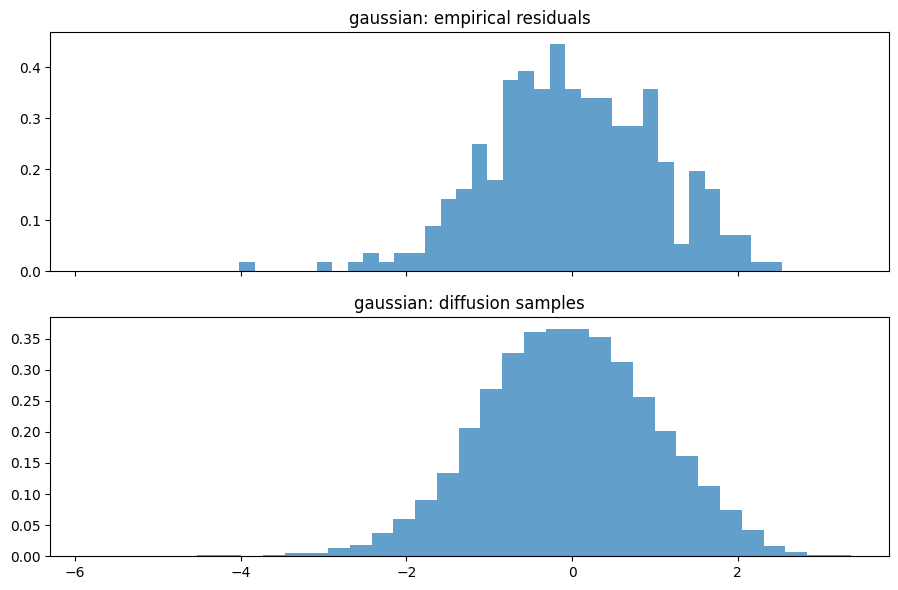

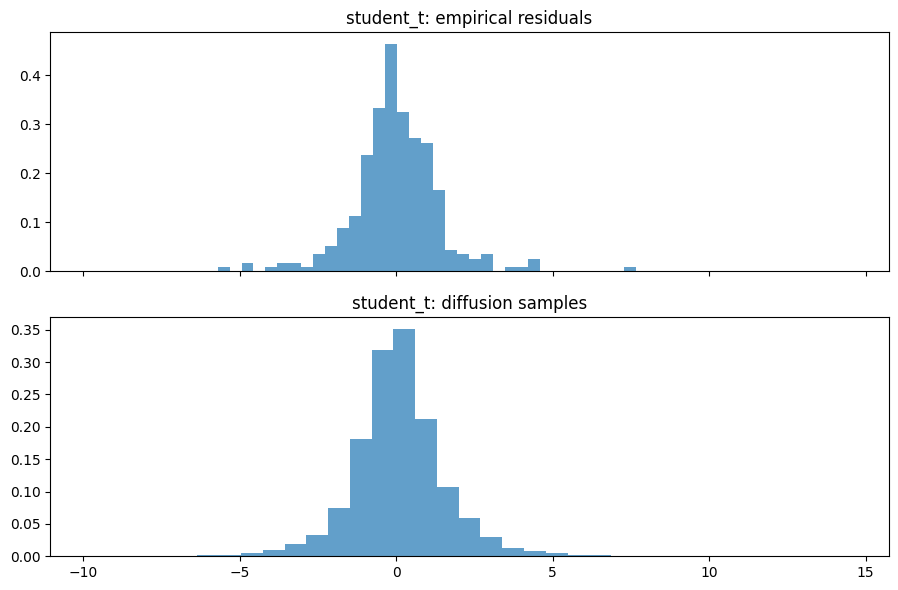

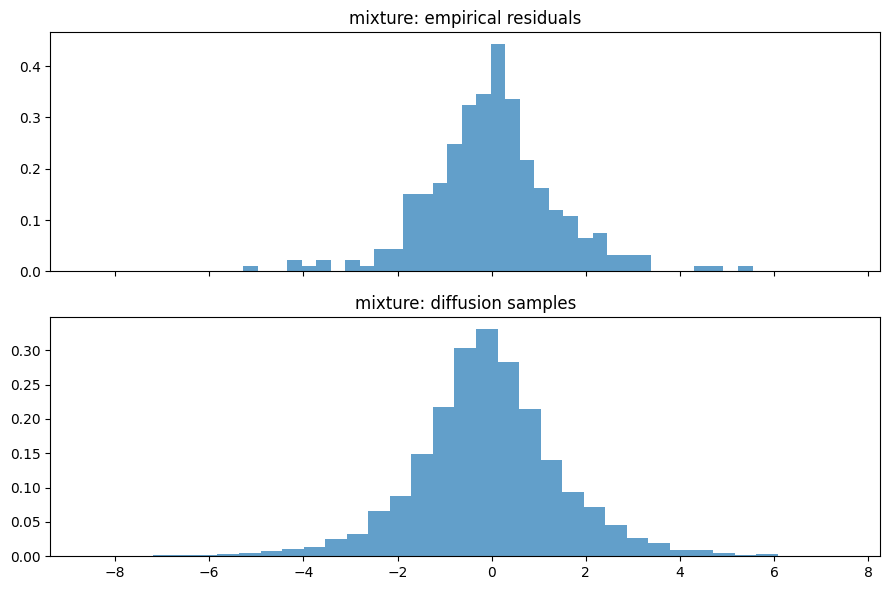

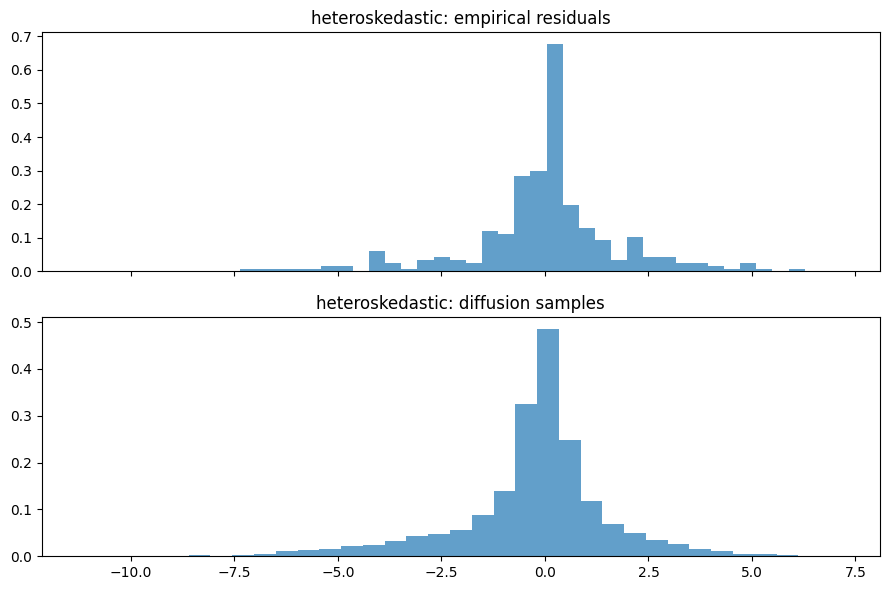

In [9]:
def plot_empirical_vs_diffusion(dgp_name, variable=0):
    empirical = residual_store[dgp_name][:, variable]
    generated = diffusion_samples[dgp_name][:, variable]

    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

    axes[0].hist(empirical, bins=35, density=True, alpha=0.7)
    axes[0].set_title(f"{dgp_name}: empirical residuals")

    axes[1].hist(generated, bins=35, density=True, alpha=0.7)
    axes[1].set_title(f"{dgp_name}: diffusion samples")

    plt.tight_layout()
    plt.show()


for dgp_name in dgp_names:
    plot_empirical_vs_diffusion(dgp_name, variable=0)

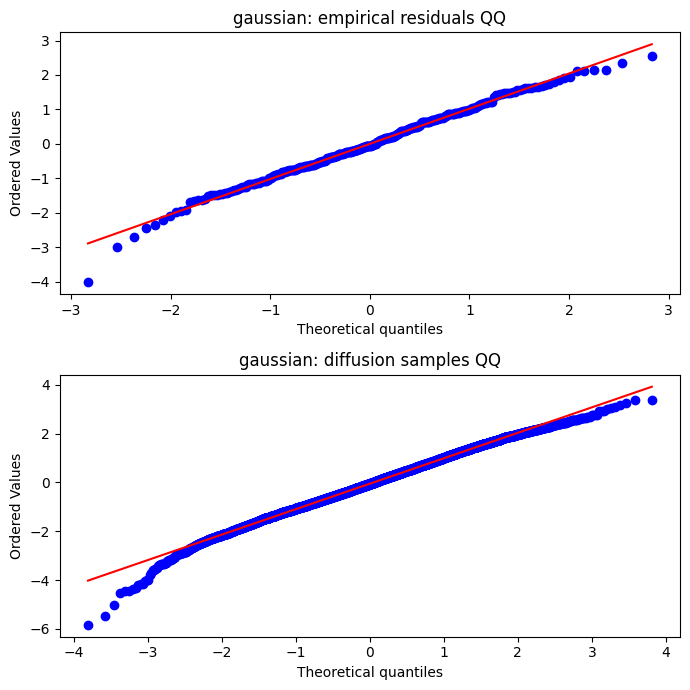

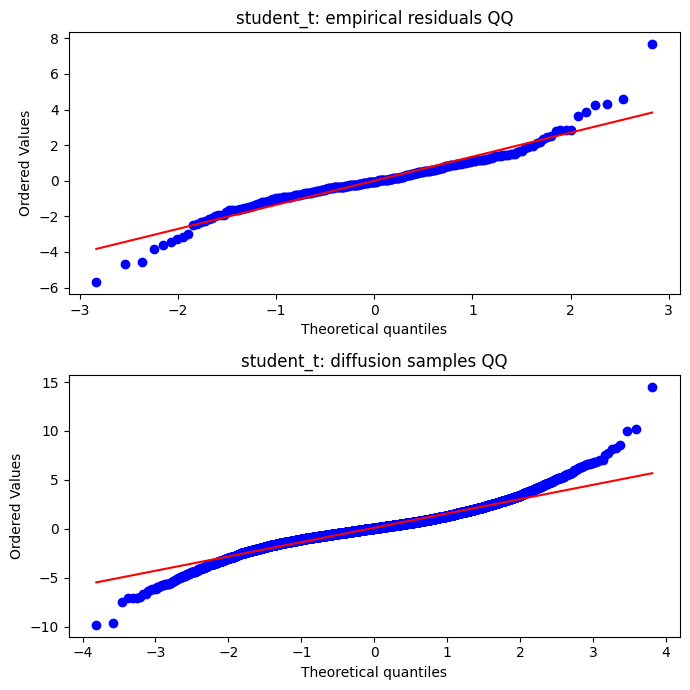

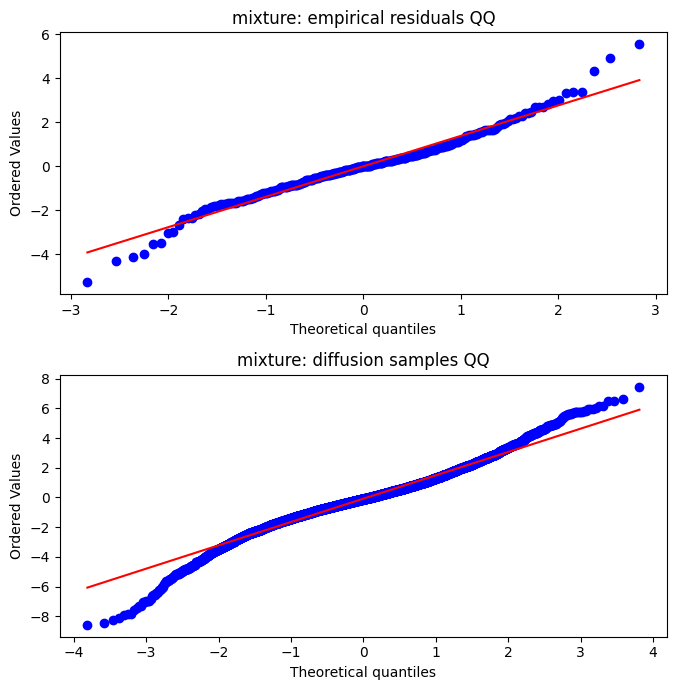

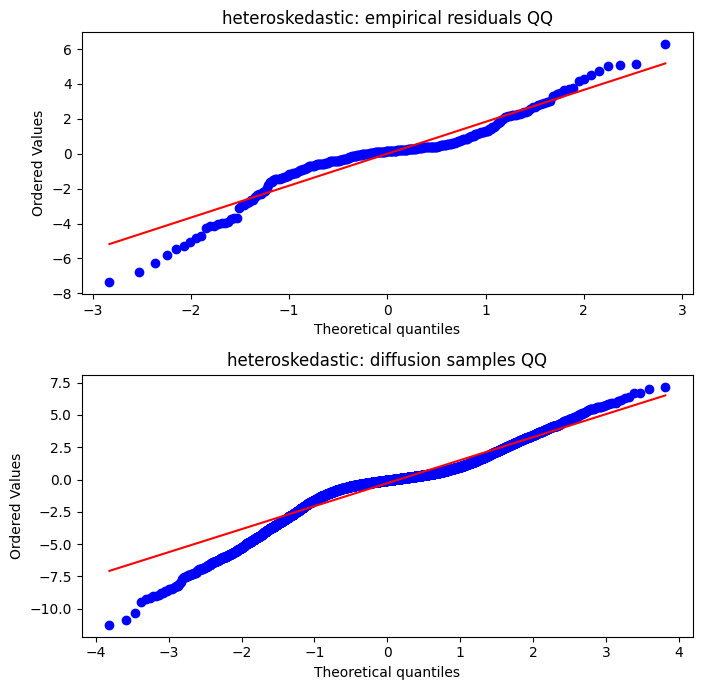

In [10]:
def plot_diffusion_qq(dgp_name, variable=0):
    empirical = residual_store[dgp_name][:, variable]
    generated = diffusion_samples[dgp_name][:, variable]

    fig, axes = plt.subplots(2, 1, figsize=(7, 7))

    stats.probplot(empirical, dist="norm", plot=axes[0])
    axes[0].set_title(f"{dgp_name}: empirical residuals QQ")

    stats.probplot(generated, dist="norm", plot=axes[1])
    axes[1].set_title(f"{dgp_name}: diffusion samples QQ")

    plt.tight_layout()
    plt.show()


for dgp_name in dgp_names:
    plot_diffusion_qq(dgp_name, variable=0)

In [11]:
quantiles = [0.01, 0.05, 0.50, 0.95, 0.99]

q_rows = []

for dgp_name in dgp_names:
    empirical = residual_store[dgp_name]
    generated = diffusion_samples[dgp_name]

    for j in range(empirical.shape[1]):
        emp_q = np.quantile(empirical[:, j], quantiles)
        gen_q = np.quantile(generated[:, j], quantiles)

        for q, e, g in zip(quantiles, emp_q, gen_q):
            q_rows.append({
                "dgp": dgp_name,
                "series": j + 1,
                "quantile": q,
                "empirical": e,
                "diffusion": g,
                "absolute_error": abs(e - g),
            })

quantile_df = pd.DataFrame(q_rows)
quantile_df

,dgp,series,quantile,empirical,diffusion,absolute_error
0,gaussian,1,0.01,-2.457322,-2.539211,0.081889
1,gaussian,1,0.05,-1.530039,-1.754376,0.224336
2,gaussian,1,0.50,-0.055020,-0.053285,0.001736
3,gaussian,1,0.95,1.619425,1.654712,0.035286
4,gaussian,1,0.99,2.140730,2.214914,0.074185
5,gaussian,2,0.01,-2.223660,-1.977286,0.246374
6,gaussian,2,0.05,-1.660227,-1.454936,0.205291
7,gaussian,2,0.50,-0.055388,-0.006017,0.049371
8,gaussian,2,0.95,1.691627,1.607600,0.084026
9,gaussian,2,0.99,2.493825,2.347186,0.146638


In [12]:
save_table_csv(
    quantile_df,
    table_dir / "diffusion_quantile_comparison.csv",
)

quantile_summary = quantile_df.groupby(["dgp", "quantile"])["absolute_error"].mean()
quantile_summary

dgp              quantile
gaussian         0.01        0.176863
                 0.05        0.162803
                 0.50        0.043999
                 0.95        0.087433
                 0.99        0.102052
heteroskedastic  0.01        0.276595
                 0.05        0.161033
                 0.50        0.079826
                 0.95        0.314994
                 0.99        0.673935
mixture          0.01        0.369666
                 0.05        0.298998
                 0.50        0.058225
                 0.95        0.420886
                 0.99        0.483236
student_t        0.01        0.622354
                 0.05        0.306690
                 0.50        0.092410
                 0.95        0.276503
                 0.99        0.207345
Name: absolute_error, dtype: float64

In [13]:
moment_rows = []

for dgp_name in dgp_names:
    empirical = residual_store[dgp_name]
    generated = diffusion_samples[dgp_name]

    emp_mean = empirical.mean(axis=0)
    gen_mean = generated.mean(axis=0)

    emp_cov = np.cov(empirical, rowvar=False)
    gen_cov = np.cov(generated, rowvar=False)

    emp_skew = stats.skew(empirical, axis=0)
    gen_skew = stats.skew(generated, axis=0)

    emp_kurt = stats.kurtosis(empirical, axis=0, fisher=False)
    gen_kurt = stats.kurtosis(generated, axis=0, fisher=False)

    moment_rows.append({
        "dgp": dgp_name,
        "mean_l2_error": np.linalg.norm(emp_mean - gen_mean),
        "cov_frobenius_error": np.linalg.norm(emp_cov - gen_cov, ord="fro"),
        "skew_l2_error": np.linalg.norm(emp_skew - gen_skew),
        "kurtosis_l2_error": np.linalg.norm(emp_kurt - gen_kurt),
    })

moment_error_df = pd.DataFrame(moment_rows)
moment_error_df

,dgp,mean_l2_error,cov_frobenius_error,skew_l2_error,kurtosis_l2_error
0,gaussian,0.070656,0.146451,0.078666,0.204665
1,student_t,0.225945,0.555401,0.445023,1.257869
2,mixture,0.130151,1.174257,0.935586,2.990959
3,heteroskedastic,0.294251,0.526899,0.395536,0.812730


In [14]:
save_table_csv(
    moment_error_df,
    table_dir / "diffusion_moment_errors.csv",
)

In [15]:
run_dir = make_run_dir(
    base_dir=ROOT / "logs" / "experiments",
    run_name="05_diffusion",
)

metrics = {
    "notebook": "05_diffusion",
    "dgp_names": dgp_names,
    "T": T,
    "beta_start": beta_start,
    "beta_end": beta_end,
    "batch_size": batch_size,
    "epochs": epochs,
    "lr": lr,
    "hidden_dim": hidden_dim,
    "time_embedding_dim": time_embedding_dim,
    "n_samples": n_samples,
    "models_saved": True,
    "samples_saved": True,
}

save_metrics_json(
    metrics,
    run_dir / "diffusion_config.json",
)

print("saved logs to:", run_dir)

saved logs to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/logs/experiments/20260610_152947_05_diffusion
